Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8680 - loss: 0.4747
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9659 - loss: 0.1113
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0725
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9672 - loss: 0.1053
0.09419194608926773 0.9706000089645386
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
7


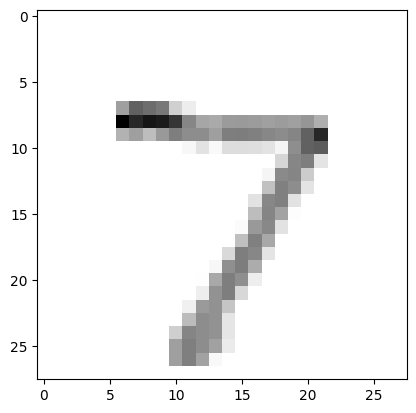

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

# Build model
model = tf.keras.models.Sequential()

# Flatten layer
model.add(tf.keras.layers.Flatten())

# Hidden layers
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(x_train, y_train, epochs=3)

# Evaluate model
val_loss, val_acc = model.evaluate(x_test, y_test)

print(val_loss, val_acc)

# Save model
model.save('new_model.keras')

# Load model
new_model = tf.keras.models.load_model('new_model.keras')

# Predictions
predictions = new_model.predict(x_test)

# Print prediction
print(np.argmax(predictions[1]))

# Show image
plt.imshow(x_test[0], cmap=plt.cm.binary)
plt.show()

NameError: name 'predictions' is not defined

In [ ]:
import os
import shutil
import gzip
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Verzeichnis für den Keras-Cache definieren
cache_dir = os.path.expanduser('~/.keras/datasets/fashion_mnist')
os.makedirs(cache_dir, exist_ok=True)

# Liste der benötigten Dateien
files = [
    'train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz'
]

# Kopiert die Dateien aus dem Hauptverzeichnis oder dem "data/"-Ordner in den Cache
for f in files:
    possible_source = os.path.join('data', f)
    if os.path.exists(f):
        shutil.copy(f, os.path.join(cache_dir, f))
        print(f"Datei {f} gefunden und in den Cache kopiert.")
    elif os.path.exists(possible_source):
        shutil.copy(possible_source, os.path.join(cache_dir, f))
        print(f"Datei {f} aus 'data/' in den Cache kopiert.")


In [2]:
print("--- Lade Datensatz ---")
try:
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()
    print("Daten erfolgreich lokal geladen!")
except Exception:
    print("[Info] Lokaler Cache unvollständig. Nutze stabile Fallback-Downloadquelle...")
    base_url = '[https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/](https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/)'
    for f in files:
        keras.utils.get_file(f, origin=base_url + f, cache_subdir='datasets/fashion_mnist')
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

# Klassennamen definieren
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Kopie der Integer-Labels für spätere Analysen behalten
y_train_classes = y_train_raw
y_test_classes = y_test_raw

print("\n--- Kontrollausgaben VOR Vorverarbeitung ---")
print("X_train Form:", X_train_raw.shape, "| Datentyp:", X_train_raw.dtype)
print("Pixel-Wertebereich:", X_train_raw.min(), "bis", X_train_raw.max())


--- Lade Datensatz ---
Daten erfolgreich lokal geladen!

--- Kontrollausgaben VOR Vorverarbeitung ---
X_train Form: (60000, 28, 28) | Datentyp: uint8
Pixel-Wertebereich: 0 bis 255


In [3]:
# 1. Normalisierung (Wertebereich 0.0 bis 1.0)
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# 2. Flatten (2D Matrix 28x28 -> 1D Vektor 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# 3. One-Hot-Encoding der Labels
y_train = keras.utils.to_categorical(y_train_raw, num_classes=10)
y_test = keras.utils.to_categorical(y_test_raw, num_classes=10)

print("--- Kontrollausgaben NACH Vorverarbeitung ---")
print("X_train Form neu:", X_train.shape, "| Datentyp:", X_train.dtype)
print("y_train Form neu:", y_train.shape, "| Datentyp:", y_train.dtype)
print("Pixel Wertebereich neu:", X_train.min(), "bis", X_train.max())

# One-Hot-Gültigkeitsprüfung
row_sums = y_train.sum(axis=1)
print("One-Hot gültig? (Zeilensumme überall 1):", (row_sums == 1).all())


--- Kontrollausgaben NACH Vorverarbeitung ---
X_train Form neu: (60000, 784) | Datentyp: float32
y_train Form neu: (60000, 10) | Datentyp: float64
Pixel Wertebereich neu: 0.0 bis 1.0
One-Hot gültig? (Zeilensumme überall 1): True


In [22]:
# Modellarchitektur aufbauen
model_baseline = keras.Sequential()
model_baseline.add(keras.layers.Input(shape=(784,)))
model_baseline.add(keras.layers.Dense(128)) 
model_baseline.add(keras.layers.Dense(10)) 

# Modell kompilieren (from_logits=True, da keine Aktivierung am Ende vorhanden ist)
model_baseline.compile(
    optimizer="sgd", 
    loss=keras.losses.CategoricalCrossentropy(from_logits=True), 
    metrics=["accuracy"]
)

print("--- Trainiere Basismodell (Baseline) ---")
history_base = model_baseline.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=20, 
    batch_size=1000, 
    verbose=1
)

# Auswertung auf den Testdaten
base_loss, base_acc = model_baseline.evaluate(X_test, y_test, verbose=0)
print(f"\n-> Baseline Test-Accuracy: {round(base_acc, 4)}")


2026-05-18 10:09:24.702323: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


--- Trainiere Basismodell (Baseline) ---
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3068 - loss: 1.9947 - val_accuracy: 0.6177 - val_loss: 1.2678
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6426 - loss: 1.1734 - val_accuracy: 0.6726 - val_loss: 1.0154
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6942 - loss: 0.9642 - val_accuracy: 0.6996 - val_loss: 0.9052
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7169 - loss: 0.8682 - val_accuracy: 0.7181 - val_loss: 0.8404
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7343 - loss: 0.8121 - val_accuracy: 0.7313 - val_loss: 0.7963
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7503 - loss: 0.7680 - val_accuracy: 0.7432 - val_loss: 0.7634
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7579 - loss: 0.7380 - val_accuracy: 0.7511 - val_loss: 0.7375
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7680 - loss: 

In [7]:
# Modellarchitektur aufbauen
model_improved = keras.Sequential()
model_improved.add(keras.layers.Input(shape=(784,)))
model_improved.add(keras.layers.Dense(128, activation="relu", kernel_initializer=keras.initializers.HeUniform()))
model_improved.add(keras.layers.Dense(10, activation="softmax"))

# Modell kompilieren
model_improved.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping (beendet das Training, falls die Genauigkeit stagniert)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
]

print("--- Trainiere verbessertes Modell ---")
history_imp = model_improved.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=30, 
    batch_size=512, 
    callbacks=callbacks, 
    verbose=1
)

# Auswertung auf den Testdaten
imp_loss, imp_acc = model_improved.evaluate(X_test, y_test, verbose=0)
print(f"\n-> Test-Accuracy (Verbessertes Modell): {round(imp_acc, 4)}")
print(f"-> Verbesserung zum Basismodell (Delta): {round(imp_acc - base_acc, 4)}")

--- Trainiere verbessertes Modell ---
Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6815 - loss: 0.9696 - val_accuracy: 0.8151 - val_loss: 0.5235
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8363 - loss: 0.4777 - val_accuracy: 0.8426 - val_loss: 0.4538
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8536 - loss: 0.4260 - val_accuracy: 0.8453 - val_loss: 0.4331
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8628 - loss: 0.3965 - val_accuracy: 0.8538 - val_loss: 0.4137
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8696 - loss: 0.3704 - val_accuracy: 0.8571 - val_loss: 0.4075
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8736 - loss: 0.3600 - val_accuracy: 0.8618 - val_loss: 0.3980
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8779 - loss: 0.3480 - val_accuracy: 0.8680 - val_loss: 0.3793
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.

NameError: name 'base_acc' is not defined

In [5]:
def plot_samples_custom(predictions, true_classes, class_names, images, sample_indices):
    num_samples = len(sample_indices)
    fig, axes = plt.subplots(num_samples, 2, figsize=(9, 2.5 * num_samples))
    
    for i, idx in enumerate(sample_indices):
        pred_probs = predictions[idx]
        
        # Falls rohe Logits übergeben werden (beim Basismodell), in Wahrscheinlichkeiten konvertieren
        if np.max(pred_probs) > 1.0 or np.min(pred_probs) < 0.0:
            e_x = np.exp(pred_probs - np.max(pred_probs))
            pred_probs = e_x / e_x.sum()
            
        pred_class = np.argmax(pred_probs)
        true_class = true_classes[idx]
        
        # Linke Spalte: Das Bild aus dem Testset
        axes[i, 0].imshow(images[idx], cmap="gray")
        axes[i, 0].axis('off')
        color = "green" if pred_class == true_class else "red"
        axes[i, 0].set_title(f"Index: {idx}\nTrue: {class_names[true_class]}\nPred: {class_names[pred_class]}", color=color, fontsize=10)
        
        # Rechte Spalte: Die Wahrscheinlichkeitsverteilung als Balken
        bars = axes[i, 1].bar(range(10), pred_probs, color="gray")
        bars[true_class].set_color("green") # Richtige Klasse wird immer GRÜN markiert
        if pred_class != true_class:
            bars[pred_class].set_color("red") # Falsche Vorhersage wird ROT markiert
            
        axes[i, 1].set_ylim(0, 1.0)
        axes[i, 1].set_xticks(range(10))
        axes[i, 1].set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
        axes[i, 1].set_ylabel("Sicherheit (0.0 - 1.0)")
        
    plt.tight_layout()
    plt.show()

# Drei feste Testbilder für den direkten Vergleich definieren
sample_indices = [0, 12, 23]



--- [HISTOGRAMME] Basismodell (Baseline) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step


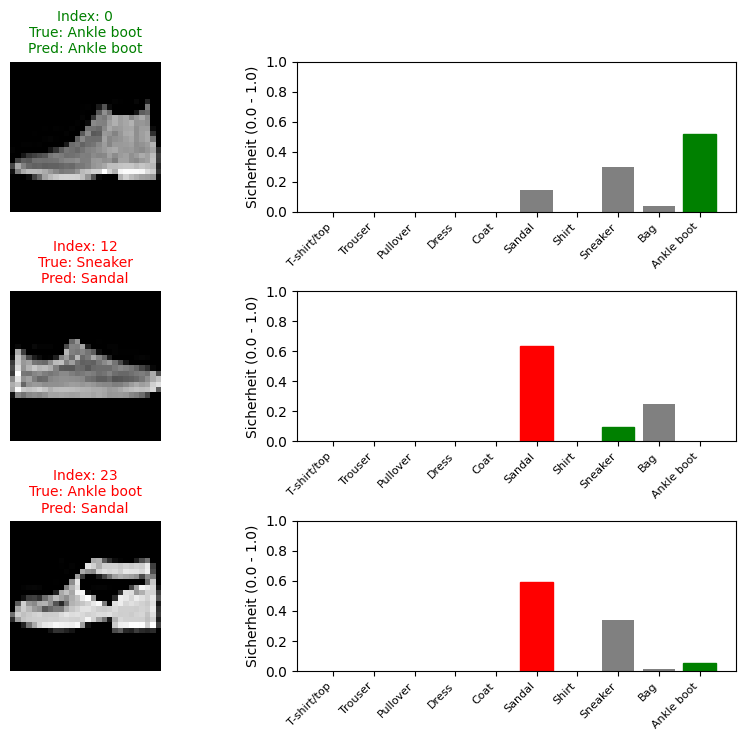

In [26]:
print("\n--- [HISTOGRAMME] Basismodell (Baseline) ---")
plot_samples_custom(
    model_baseline.predict(X_test), 
    y_test_classes, 
    classes, 
    X_test.reshape(-1, 28, 28), 
    sample_indices
)



--- [HISTOGRAMME] Verbessertes Modell ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


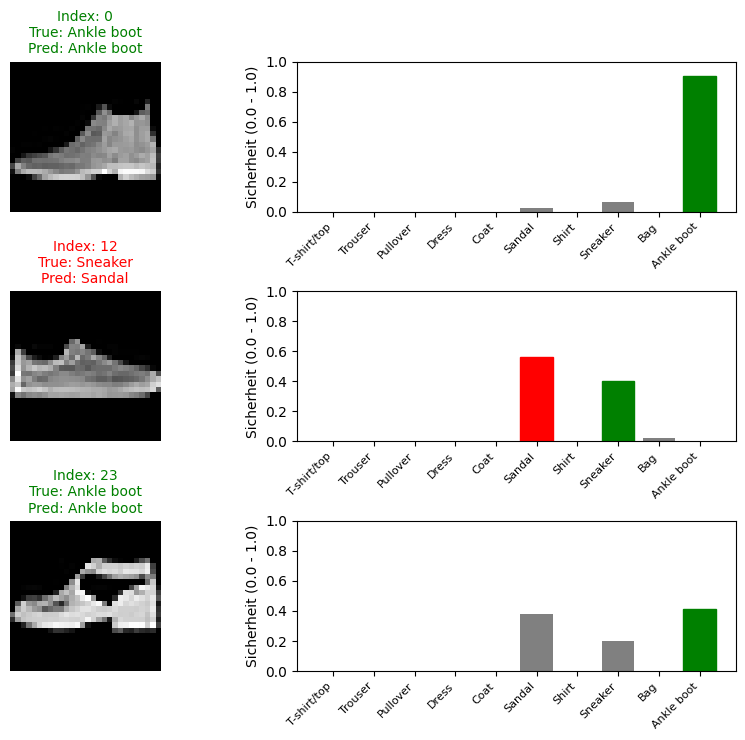

In [8]:
print("\n--- [HISTOGRAMME] Verbessertes Modell ---")
plot_samples_custom(
    model_improved.predict(X_test), 
    y_test_classes, 
    classes, 
    X_test.reshape(-1, 28, 28), 
    sample_indices
)
